In [3]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

np.random.seed(42)

pd.set_option("display.max_columns", 50)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
pd.set_option("display.width", 140)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.figsize": (12, 5),
    "figure.dpi": 100,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

COLORS = {
    "primary": "#2563eb",
    "secondary": "#7c3aed",
    "success": "#059669",
    "danger": "#dc2626",
    "warning": "#d97706",
    "info": "#0891b2",
    "muted": "#64748b",
    "palette": ["#2563eb", "#7c3aed", "#059669", "#d97706",
                "#dc2626", "#0891b2", "#db2777", "#4f46e5"],
}

print("✅ Libraries loaded")

✅ Libraries loaded


In [4]:
def resolve_dataset_path() -> Path:
    candidates = [
        Path("../../datasets/smart_retail_sales_dataset.csv"),  # from backend/notebooks/
        Path("../datasets/smart_retail_sales_dataset.csv"),
        Path("datasets/smart_retail_sales_dataset.csv"),
        Path("smart_retail_sales_dataset.csv"),
    ]
    for p in candidates:
        if p.exists():
            return p.resolve()
    raise FileNotFoundError(
        "Dataset not found. Put smart_retail_sales_dataset.csv in datasets/"
    )

DATA_PATH = resolve_dataset_path()
print(f"📂 Dataset: {DATA_PATH}")
print(f"📦 Size   : {DATA_PATH.stat().st_size / (1024**2):.1f} MB")

📂 Dataset: C:\Users\ASUS\OneDrive\Desktop\claude-test\smart-retail-intelligence-platform\datasets\smart_retail_sales_dataset.csv
📦 Size   : 72.1 MB


In [5]:
df = pd.read_csv(DATA_PATH, low_memory=False)
df["date"] = pd.to_datetime(df["date"], errors="coerce")

print(f"✅ Loaded")
print(f"   Shape : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"   Memory: {df.memory_usage(deep=True).sum() / (1024**2):.1f} MB")

✅ Loaded
   Shape : 300,000 rows × 34 columns
   Memory: 306.4 MB


In [6]:
print("=" * 70)
print("DATASET SHAPE")
print("=" * 70)
print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}\n")

print("COLUMN LIST")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2d}. {col}")

print("\n" + "=" * 70)
print("DATA TYPES / NULLS / NUNIQUE")
print("=" * 70)
dtype_df = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "non_null": df.count().values,
    "null_count": df.isnull().sum().values,
    "null_pct": (df.isnull().sum() / len(df) * 100).round(2).values,
    "nunique": df.nunique().values,
})
display(dtype_df)

DATASET SHAPE
Rows    : 300,000
Columns : 34

COLUMN LIST
   1. sale_id
   2. invoice_number
   3. date
   4. store_id
   5. store_name
   6. city
   7. state
   8. product_id
   9. sku
  10. product_name
  11. category
  12. brand
  13. supplier
  14. cost_price
  15. selling_price
  16. quantity_sold
  17. revenue
  18. profit
  19. current_stock
  20. reorder_level
  21. promotion
  22. discount_percent
  23. holiday
  24. festival
  25. day_of_week
  26. week_of_year
  27. month
  28. quarter
  29. year
  30. season
  31. is_weekend
  32. weather
  33. customer_type
  34. payment_method

DATA TYPES / NULLS / NUNIQUE


,column,dtype,non_null,null_count,null_pct,nunique
0,sale_id,int64,300000,0,0.00,300000
1,invoice_number,object,300000,0,0.00,92452
2,date,datetime64[ns],300000,0,0.00,1095
3,store_id,int64,300000,0,0.00,10
4,store_name,object,300000,0,0.00,10
5,city,object,300000,0,0.00,10
6,state,object,300000,0,0.00,8
7,product_id,int64,300000,0,0.00,200
8,sku,object,300000,0,0.00,200
9,product_name,object,300000,0,0.00,200


In [7]:
print("FIRST 5 ROWS")
display(df.head())

print("\nRANDOM 5 ROWS")
display(df.sample(5, random_state=42))

print("\nNUMERICAL DESCRIBE")
display(df.describe().T)

print("\nCATEGORICAL DESCRIBE")
display(df.describe(include=["object", "string"]).T)

FIRST 5 ROWS


,sale_id,invoice_number,date,store_id,store_name,city,state,product_id,sku,product_name,category,brand,supplier,cost_price,selling_price,quantity_sold,revenue,profit,current_stock,reorder_level,promotion,discount_percent,holiday,festival,day_of_week,week_of_year,month,quarter,year,season,is_weekend,weather,customer_type,payment_method
0,1,INV-2021-97240,2021-01-01,1,SmartRetail Mumbai,Mumbai,Maharashtra,129,SKU-BOO-0129,DailyFresh Book 129,Books,DailyFresh,Supplier_West,623.10,873.21,3,"2,619.63",750.33,130,41,NaN,0.00,NaN,NaN,Friday,53,1,1,2021,Winter,0,Foggy,Member,Credit Card
1,2,INV-2021-32792,2021-01-01,1,SmartRetail Mumbai,Mumbai,Maharashtra,84,SKU-CLO-0084,DailyFresh Clothing 84,Clothing,DailyFresh,Supplier_North,"2,082.53","2,848.82",4,"11,395.28","3,065.16",121,11,NaN,0.00,NaN,NaN,Friday,53,1,1,2021,Winter,0,Clear,Regular,UPI
2,3,INV-2021-32792,2021-01-01,1,SmartRetail Mumbai,Mumbai,Maharashtra,195,SKU-SPO-0195,DailyFresh Sport 195,Sports,DailyFresh,Supplier_East,"3,158.10","4,812.53",8,"34,650.22","9,385.42",111,41,10% Off,0.10,NaN,NaN,Friday,53,1,1,2021,Winter,0,Cold,Regular,Debit Card
3,4,INV-2021-32792,2021-01-01,1,SmartRetail Mumbai,Mumbai,Maharashtra,30,SKU-SPO-0030,BrandC Sport 30,Sports,BrandC,Supplier_East,889.98,"1,564.42",5,"7,822.10","3,372.20",38,28,NaN,0.00,NaN,NaN,Friday,53,1,1,2021,Winter,0,Clear,Regular,Credit Card
4,5,INV-2021-99773,2021-01-01,1,SmartRetail Mumbai,Mumbai,Maharashtra,9,SKU-ELE-0009,BrandC Electronic 9,Electronics,BrandC,Global_Imports,"31,162.15","40,582.92",3,"85,224.13","-8,262.32",103,29,Clearance,0.30,NaN,NaN,Friday,53,1,1,2021,Winter,0,Clear,Regular,UPI



RANDOM 5 ROWS


,sale_id,invoice_number,date,store_id,store_name,city,state,product_id,sku,product_name,category,brand,supplier,cost_price,selling_price,quantity_sold,revenue,profit,current_stock,reorder_level,promotion,discount_percent,holiday,festival,day_of_week,week_of_year,month,quarter,year,season,is_weekend,weather,customer_type,payment_method
4941,4942,INV-2023-25567,2021-01-19,2,SmartRetail Delhi,New Delhi,Delhi,5,SKU-HOM-0005,BrandE Home Appliance 5,Home Appliances,BrandE,Supplier_North,"6,780.60","10,271.62",4,"36,977.83","9,855.43",174,42,10% Off,0.10,NaN,NaN,Tuesday,3,1,1,2021,Winter,0,Clear,New,Credit Card
51775,51776,INV-2022-70138,2021-07-09,6,SmartRetail Chennai,Chennai,Tamil Nadu,93,SKU-BOO-0093,TechPro Book 93,Books,TechPro,Supplier_South,229.91,356.70,1,356.70,126.79,39,35,NaN,0.00,NaN,NaN,Friday,27,7,3,2021,Monsoon,0,Rainy,New,Credit Card
115253,115254,INV-2022-30199,2022-02-26,10,SmartRetail Surat,Surat,Gujarat,162,SKU-BOO-0162,EcoLife Book 162,Books,EcoLife,Supplier_East,"4,612.27","5,703.75",3,"17,111.25","3,274.44",93,25,NaN,0.00,NaN,NaN,Saturday,8,2,1,2022,Winter,1,Clear,Regular,Credit Card
299321,299322,INV-2023-16093,2023-12-29,6,SmartRetail Chennai,Chennai,Tamil Nadu,5,SKU-HOM-0005,BrandE Home Appliance 5,Home Appliances,BrandE,Supplier_North,"6,780.60","10,271.62",3,"30,814.86","10,473.06",143,41,NaN,0.00,NaN,NaN,Friday,52,12,4,2023,Winter,0,Cold,Regular,UPI
173570,173571,INV-2021-18922,2022-09-26,2,SmartRetail Delhi,New Delhi,Delhi,115,SKU-CLO-0115,BrandE Clothing 115,Clothing,BrandE,Global_Imports,529.06,948.07,2,"1,896.14",838.02,77,12,NaN,0.00,NaN,NaN,Monday,39,9,3,2022,Monsoon,0,Humid,Regular,Credit Card



NUMERICAL DESCRIBE


,count,mean,min,25%,50%,75%,max,std
sale_id,"300,000.00","150,000.50",1.00,"75,000.75","150,000.50","225,000.25","300,000.00","86,602.68"
date,300000,2022-07-02 08:14:17.376000,2021-01-01 00:00:00,2021-10-02 00:00:00,2022-07-03 00:00:00,2023-04-01 00:00:00,2023-12-31 00:00:00,NaN
store_id,"300,000.00",5.49,1.00,3.00,5.00,8.00,10.00,2.87
product_id,"300,000.00",100.44,1.00,50.00,100.00,150.00,200.00,57.75
cost_price,"300,000.00","6,655.94",41.12,864.37,"2,263.50","4,666.87","49,891.54","11,183.35"
selling_price,"300,000.00","10,063.27",50.25,"1,272.51","3,533.45","7,118.23","84,274.60","17,289.04"
quantity_sold,"300,000.00",3.77,1.00,2.00,3.00,5.00,55.00,2.28
revenue,"300,000.00","31,220.67",25.12,"3,227.40","9,152.80","24,266.09","1,404,596.54","64,559.77"
profit,"300,000.00","7,199.80","-159,039.41",188.86,"1,584.32","5,571.11","476,731.19","21,569.27"
current_stock,"300,000.00",103.98,10.00,66.00,104.00,141.00,198.00,44.79



CATEGORICAL DESCRIBE


,count,unique,top,freq
invoice_number,300000,92452,INV-2022-46001,22
store_name,300000,10,SmartRetail Pune,30266
city,300000,10,Pune,30266
state,300000,8,Maharashtra,60273
sku,300000,200,SKU-HOM-0073,1611
product_name,300000,200,BrandE Home Appliance 73,1611
category,300000,8,Books,46603
brand,300000,8,BrandD,50905
supplier,300000,5,Supplier_North,68513
promotion,151962,4,20% Off,41094


Columns with NaN: 3


,column,missing_count,missing_pct
23,festival,295933,98.64
22,holiday,295933,98.64
20,promotion,148038,49.35


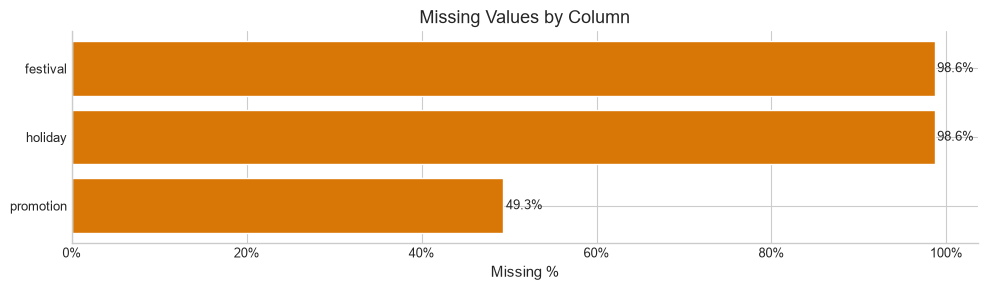


String 'None' / empty placeholders:
  promotion       → 148,038 (49.3%)
  holiday         → 295,933 (98.6%)
  festival        → 295,933 (98.6%)


In [8]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(3)
missing_df = pd.DataFrame({
    "column": missing.index,
    "missing_count": missing.values,
    "missing_pct": missing_pct.values,
}).sort_values("missing_count", ascending=False)
missing_df = missing_df[missing_df["missing_count"] > 0]

print(f"Columns with NaN: {len(missing_df)}")
if len(missing_df) == 0:
    print("✅ No NaN missing values")
else:
    display(missing_df)
    fig, ax = plt.subplots(figsize=(10, max(3, len(missing_df) * 0.4)))
    bars = ax.barh(missing_df["column"][::-1], missing_df["missing_pct"][::-1],
                   color=COLORS["warning"], edgecolor="white")
    ax.set_xlabel("Missing %")
    ax.set_title("Missing Values by Column")
    ax.xaxis.set_major_formatter(mticker.PercentFormatter())
    for bar, pct in zip(bars, missing_df["missing_pct"][::-1]):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                f"{pct:.1f}%", va="center", fontsize=9)
    plt.tight_layout()
    plt.show()

print("\nString 'None' / empty placeholders:")
for col in ["promotion", "holiday", "festival"]:
    if col in df.columns:
        vals = df[col].astype(str).str.strip().str.lower()
        none_like = vals.isin(["none", "nan", "null", "", "na", "n/a"])
        print(f"  {col:15s} → {none_like.sum():,} ({none_like.mean()*100:.1f}%)")

In [9]:
dup_full = df.duplicated().sum()
dup_sale_id = df.duplicated(subset=["sale_id"]).sum() if "sale_id" in df.columns else "N/A"
dup_inv = df.duplicated(subset=["invoice_number", "product_id"]).sum()

print(f"Exact duplicates              : {dup_full:,}")
print(f"Duplicate sale_id             : {dup_sale_id}")
print(f"Duplicate (invoice+product)   : {dup_inv:,}")

checks = []
checks.append(("quantity_sold < 0", (df["quantity_sold"] < 0).sum()))
checks.append(("quantity_sold == 0", (df["quantity_sold"] == 0).sum()))
for col in ["cost_price", "selling_price"]:
    checks.append((f"{col} < 0", (df[col] < 0).sum()))
checks.append(("selling_price < cost_price", (df["selling_price"] < df["cost_price"]).sum()))
checks.append(("revenue < 0", (df["revenue"] < 0).sum()))
checks.append(("current_stock < 0", (df["current_stock"] < 0).sum()))
checks.append(("date > today", (df["date"] > pd.Timestamp.today()).sum()))
checks.append(("date is null", df["date"].isna().sum()))
checks.append(("discount not in [0,1]",
               ((df["discount_percent"] < 0) | (df["discount_percent"] > 1)).sum()))

check_df = pd.DataFrame(checks, columns=["check", "count"])
check_df["status"] = check_df["count"].apply(lambda x: "✅ OK" if x == 0 else "⚠️ Review")
display(check_df)
print("\nNote: Negative profit is normal under BOGO / Clearance.")

Exact duplicates              : 0
Duplicate sale_id             : 0
Duplicate (invoice+product)   : 2,743


,check,count,status
0,quantity_sold < 0,0,✅ OK
1,quantity_sold == 0,0,✅ OK
2,cost_price < 0,0,✅ OK
3,selling_price < 0,0,✅ OK
4,selling_price < cost_price,0,✅ OK
5,revenue < 0,0,✅ OK
6,current_stock < 0,0,✅ OK
7,date > today,0,✅ OK
8,date is null,0,✅ OK
9,"discount not in [0,1]",0,✅ OK



Note: Negative profit is normal under BOGO / Clearance.


,column,q1,q3,iqr,lower_bound,upper_bound,outlier_count,outlier_pct
0,cost_price,864.37,"4,666.87","3,802.50","-4,839.38","10,370.62",53940,17.98
1,selling_price,"1,272.51","7,118.23","5,845.72","-7,496.07","15,886.81",50969,16.99
2,quantity_sold,2.00,5.00,3.00,-2.50,9.50,5106,1.70
3,revenue,"3,227.40","24,266.09","21,038.69","-28,330.63","55,824.12",42230,14.08
4,profit,188.86,"5,571.11","5,382.25","-7,884.52","13,644.49",45612,15.20
5,current_stock,66.00,141.00,75.00,-46.50,253.50,0,0.00
6,reorder_level,19.00,40.00,21.00,-12.50,71.50,0,0.00
7,discount_percent,0.00,0.20,0.20,-0.30,0.50,0,0.00


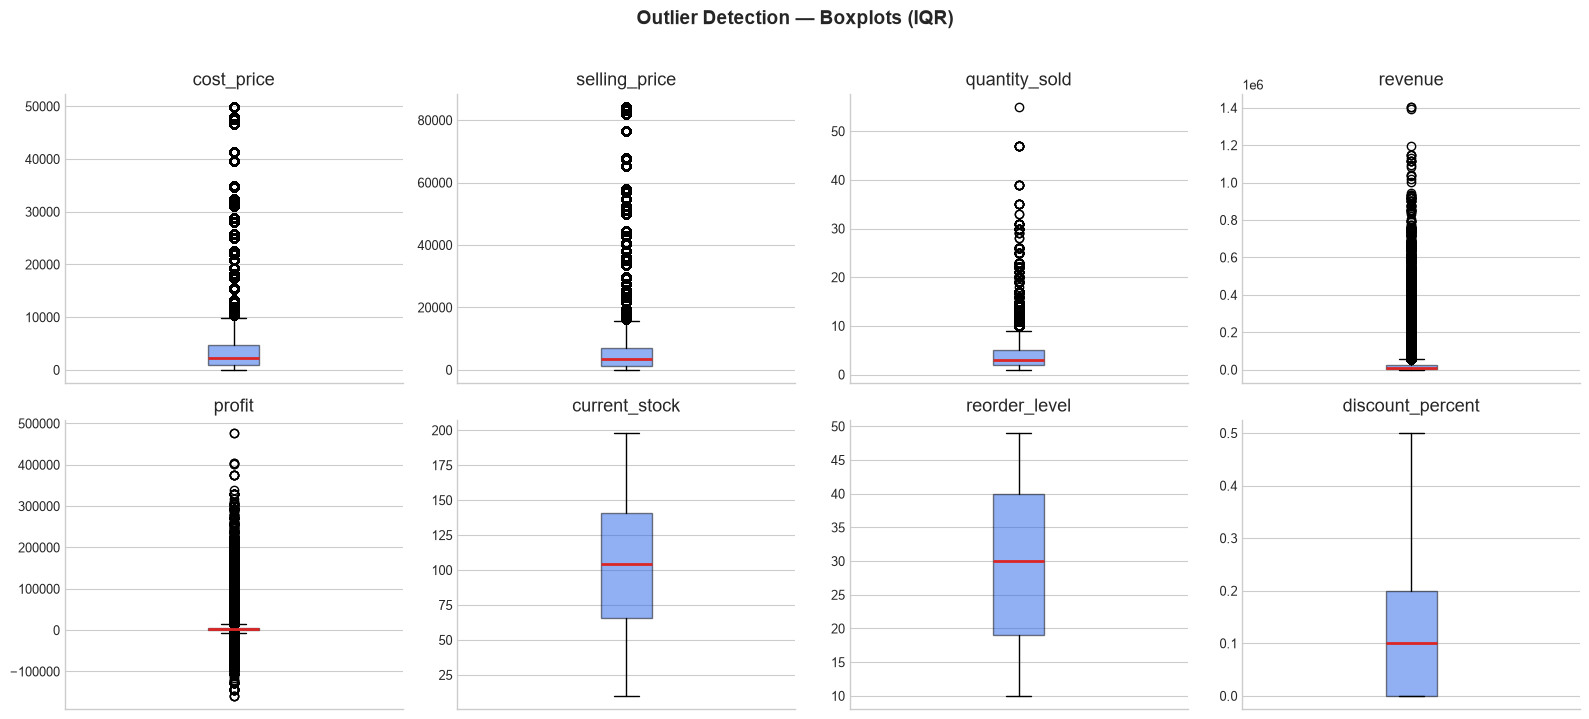

In [10]:
num_cols = ["cost_price", "selling_price", "quantity_sold", "revenue",
            "profit", "current_stock", "reorder_level", "discount_percent"]
num_cols = [c for c in num_cols if c in df.columns]

outlier_summary = []
for col in num_cols:
    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary.append({
        "column": col, "q1": q1, "q3": q3, "iqr": iqr,
        "lower_bound": lower, "upper_bound": upper,
        "outlier_count": n_out,
        "outlier_pct": round(n_out / len(df) * 100, 2),
    })
display(pd.DataFrame(outlier_summary))

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    ax = axes[i]
    ax.boxplot(df[col].dropna(), vert=True, patch_artist=True,
               boxprops=dict(facecolor=COLORS["primary"], alpha=0.5),
               medianprops=dict(color=COLORS["danger"], linewidth=2))
    ax.set_title(col)
    ax.set_xticks([])
for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)
fig.suptitle("Outlier Detection — Boxplots (IQR)", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

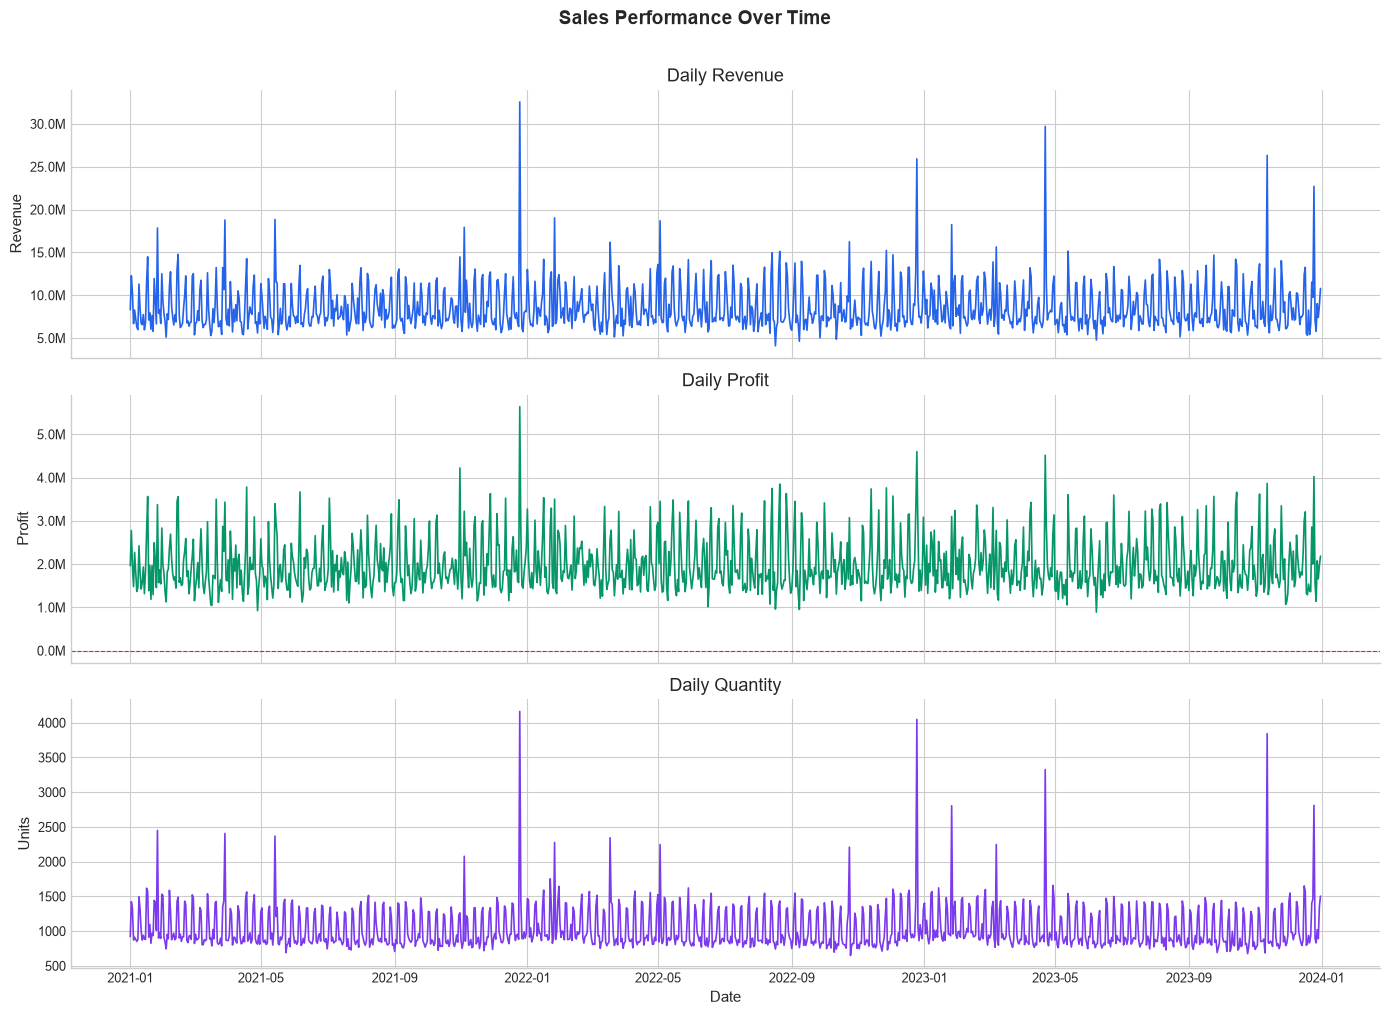

Date range : 2021-01-01 → 2023-12-31
Total days : 1,095
Avg daily revenue : 8,553,608
Avg daily profit  : 1,972,547


In [11]:
daily = df.groupby("date").agg(
    revenue=("revenue", "sum"),
    profit=("profit", "sum"),
    quantity=("quantity_sold", "sum"),
    transactions=("sale_id", "count"),
).reset_index().sort_values("date")

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
axes[0].plot(daily["date"], daily["revenue"], color=COLORS["primary"], linewidth=1.2)
axes[0].set_ylabel("Revenue"); axes[0].set_title("Daily Revenue")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))

axes[1].plot(daily["date"], daily["profit"], color=COLORS["success"], linewidth=1.2)
axes[1].axhline(0, color=COLORS["danger"], linestyle="--", linewidth=0.8)
axes[1].set_ylabel("Profit"); axes[1].set_title("Daily Profit")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))

axes[2].plot(daily["date"], daily["quantity"], color=COLORS["secondary"], linewidth=1.2)
axes[2].set_ylabel("Units"); axes[2].set_title("Daily Quantity"); axes[2].set_xlabel("Date")

fig.suptitle("Sales Performance Over Time", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

print(f"Date range : {daily['date'].min().date()} → {daily['date'].max().date()}")
print(f"Total days : {daily['date'].nunique():,}")
print(f"Avg daily revenue : {daily['revenue'].mean():,.0f}")
print(f"Avg daily profit  : {daily['profit'].mean():,.0f}")

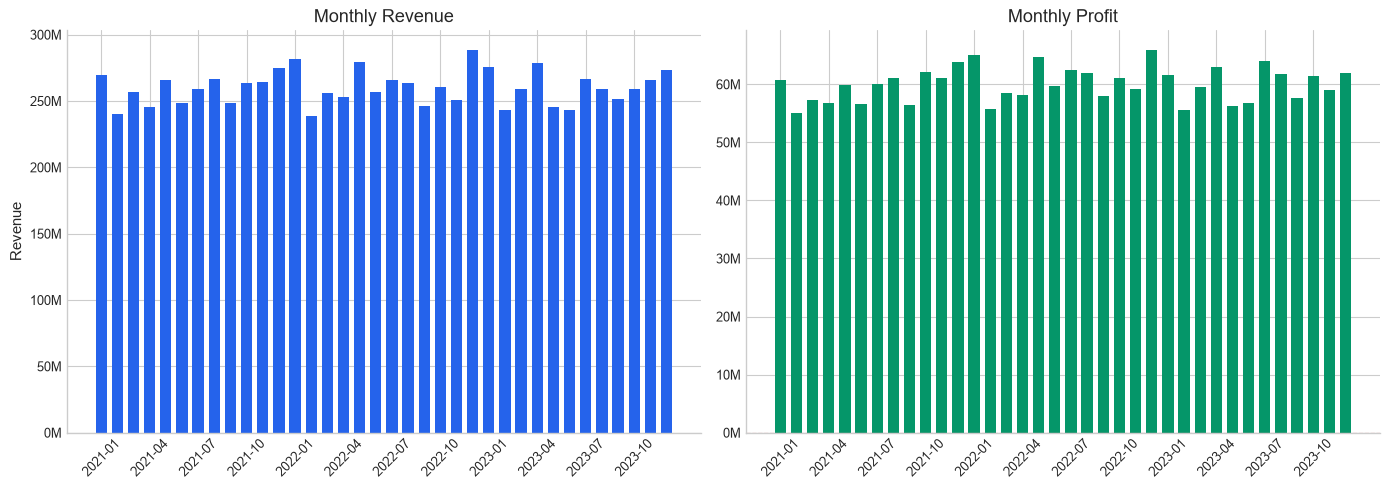

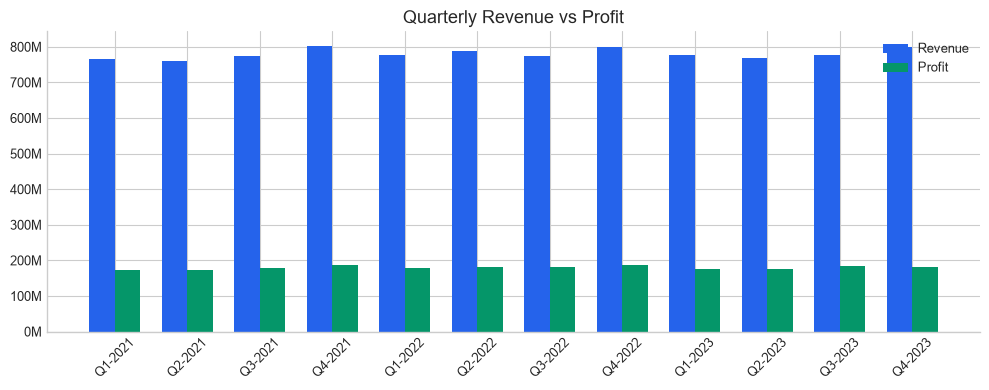

,year,revenue,profit,quantity,transactions
0,2021,"3,102,781,741.05","711,038,606.61",375170,99631
1,2022,"3,141,454,571.46","730,225,999.72",378403,100257
2,2023,"3,121,964,478.56","718,674,323.29",378579,100112


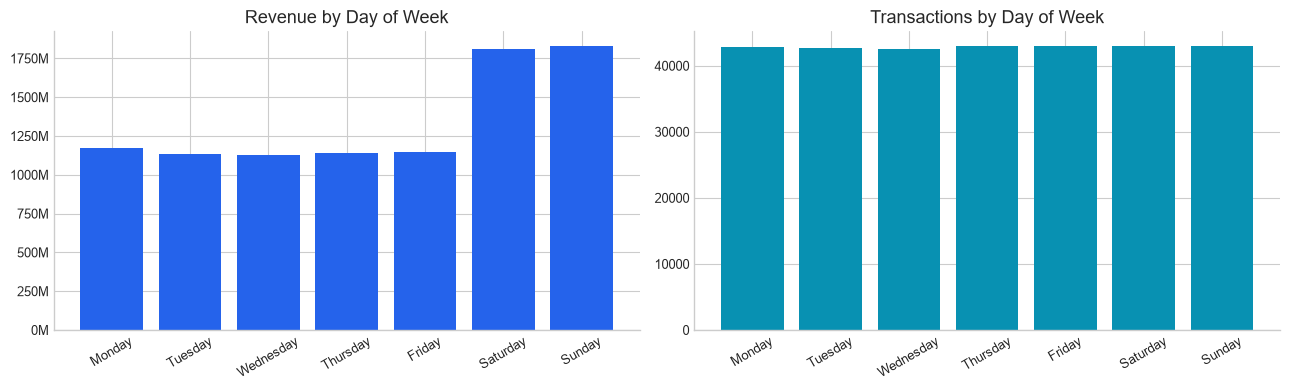

,day_of_week,revenue,profit,quantity,transactions
0,Monday,"1,169,370,257.82","271,484,283.10",139903,42812
1,Tuesday,"1,132,899,045.91","263,662,416.70",137590,42656
2,Wednesday,"1,129,828,275.68","259,900,581.25",136251,42488
3,Thursday,"1,143,218,804.67","262,867,444.42",138918,43016
4,Friday,"1,146,723,951.60","265,341,705.59",138477,42992
5,Saturday,"1,812,441,824.39","415,497,744.59",220114,43035
6,Sunday,"1,831,718,631.00","421,184,753.97",220899,43001


In [12]:
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["quarter"] = df["date"].dt.quarter
df["week_of_year"] = df["date"].dt.isocalendar().week.astype(int)
df["day_of_week"] = df["date"].dt.day_name()

# Monthly
monthly = df.groupby(["year", "month"]).agg(
    revenue=("revenue", "sum"), profit=("profit", "sum"), quantity=("quantity_sold", "sum")
).reset_index()
monthly["period"] = monthly["year"].astype(str) + "-" + monthly["month"].astype(str).str.zfill(2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
step = max(1, len(monthly) // 12)
axes[0].bar(range(len(monthly)), monthly["revenue"], color=COLORS["primary"], width=0.7)
axes[0].set_title("Monthly Revenue"); axes[0].set_ylabel("Revenue")
axes[0].set_xticks(range(0, len(monthly), step))
axes[0].set_xticklabels(monthly["period"].iloc[::step], rotation=45)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.0f}M"))

axes[1].bar(range(len(monthly)), monthly["profit"], color=COLORS["success"], width=0.7)
axes[1].axhline(0, color=COLORS["danger"], linestyle="--", linewidth=0.8)
axes[1].set_title("Monthly Profit")
axes[1].set_xticks(range(0, len(monthly), step))
axes[1].set_xticklabels(monthly["period"].iloc[::step], rotation=45)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.0f}M"))
plt.tight_layout(); plt.show()

# Quarterly
quarterly = df.groupby(["year", "quarter"]).agg(
    revenue=("revenue", "sum"), profit=("profit", "sum")
).reset_index()
quarterly["period"] = "Q" + quarterly["quarter"].astype(str) + "-" + quarterly["year"].astype(str)

fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(quarterly)); w = 0.35
ax.bar(x - w/2, quarterly["revenue"], w, label="Revenue", color=COLORS["primary"])
ax.bar(x + w/2, quarterly["profit"], w, label="Profit", color=COLORS["success"])
ax.set_xticks(x); ax.set_xticklabels(quarterly["period"], rotation=45)
ax.set_title("Quarterly Revenue vs Profit"); ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.0f}M"))
plt.tight_layout(); plt.show()

# Yearly
yearly = df.groupby("year").agg(
    revenue=("revenue", "sum"), profit=("profit", "sum"),
    quantity=("quantity_sold", "sum"), transactions=("sale_id", "count")
).reset_index()
display(yearly)

# Day of week
dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
dow = df.groupby("day_of_week").agg(
    revenue=("revenue", "sum"), profit=("profit", "sum"),
    quantity=("quantity_sold", "sum"), transactions=("sale_id", "count")
).reindex(dow_order).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(dow["day_of_week"], dow["revenue"], color=COLORS["primary"])
axes[0].set_title("Revenue by Day of Week"); axes[0].tick_params(axis="x", rotation=30)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.0f}M"))
axes[1].bar(dow["day_of_week"], dow["transactions"], color=COLORS["info"])
axes[1].set_title("Transactions by Day of Week"); axes[1].tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()
display(dow)

🏆 TOP 10 BY REVENUE


,product_name,category,brand,revenue,profit,quantity,profit_margin_pct
106,TechPro Electronic 107,Electronics,TechPro,"392,104,431.42","135,000,790.45",5401,34.43
105,BrandD Electronic 106,Electronics,BrandD,"380,671,647.18","122,713,970.91",5373,32.24
109,TechPro Electronic 110,Electronics,TechPro,"372,408,277.12","130,208,572.32",5188,34.96
139,BrandE Electronic 140,Electronics,BrandE,"352,168,196.91","84,385,560.30",5373,23.96
94,BrandE Electronic 95,Electronics,BrandE,"311,721,342.92","84,983,143.10",5478,27.26
38,BrandE Electronic 39,Electronics,BrandE,"308,690,151.17","45,811,626.91",5269,14.84
179,EcoLife Electronic 180,Electronics,EcoLife,"294,992,285.81","81,609,727.91",5154,27.67
149,EcoLife Electronic 150,Electronics,EcoLife,"264,648,629.85","52,231,176.77",5362,19.74
67,BrandB Electronic 68,Electronics,BrandB,"264,256,402.39","15,241,117.80",5339,5.77
91,DailyFresh Electronic 92,Electronics,DailyFresh,"257,599,339.99","67,008,157.27",5472,26.01



📉 WORST 10 BY REVENUE


,product_name,category,brand,revenue,profit,quantity,profit_margin_pct
137,BrandA Grocerie 138,Groceries,BrandA,"273,782.09","14,232.65",6312,5.20
65,BrandD Grocerie 66,Groceries,BrandD,"321,842.59","49,237.39",5810,15.30
20,BrandA Grocerie 21,Groceries,BrandA,"351,942.60","63,340.52",6236,18.00
107,BrandB Grocerie 108,Groceries,BrandB,"418,303.36","107,452.84",5658,25.69
199,BrandD Grocerie 200,Groceries,BrandD,"627,203.33","99,697.41",6256,15.90
189,BrandA Grocerie 190,Groceries,BrandA,"647,204.25","48,377.45",6061,7.47
43,TechPro Grocerie 44,Groceries,TechPro,"663,708.89","151,553.09",6108,22.83
35,BrandB Grocerie 36,Groceries,BrandB,"890,349.12","98,370.92",6110,11.05
18,BrandE Sport 19,Sports,BrandE,"1,137,873.72","227,397.62",5155,19.98
131,EcoLife Grocerie 132,Groceries,EcoLife,"1,154,310.32","219,911.08",6353,19.05


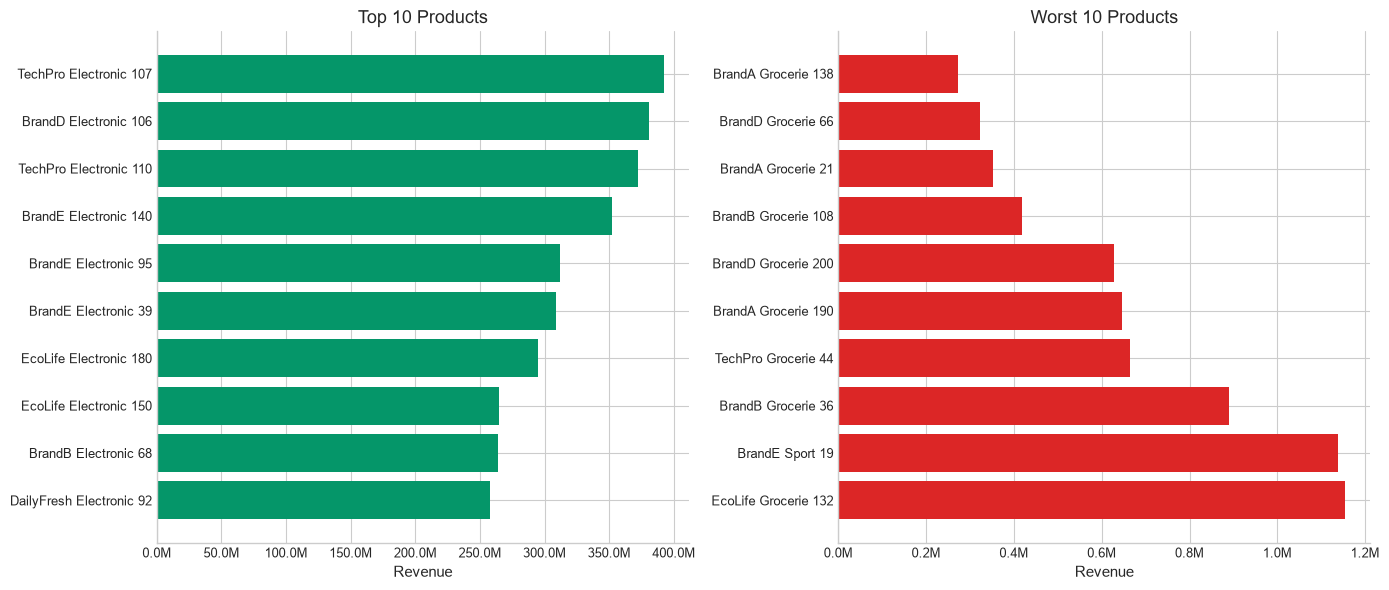


Loss-making products: 0


,product_name,category,brand,revenue,profit,quantity,profit_margin_pct


In [13]:
product_perf = df.groupby(["product_id", "product_name", "category", "brand"]).agg(
    revenue=("revenue", "sum"), profit=("profit", "sum"),
    quantity=("quantity_sold", "sum"), transactions=("sale_id", "count"),
    avg_selling_price=("selling_price", "mean"),
).reset_index()
product_perf["profit_margin_pct"] = np.where(
    product_perf["revenue"] > 0,
    product_perf["profit"] / product_perf["revenue"] * 100, np.nan)

top10 = product_perf.nlargest(10, "revenue")
worst10 = product_perf.nsmallest(10, "revenue")

print("🏆 TOP 10 BY REVENUE")
display(top10[["product_name", "category", "brand", "revenue", "profit", "quantity", "profit_margin_pct"]])

print("\n📉 WORST 10 BY REVENUE")
display(worst10[["product_name", "category", "brand", "revenue", "profit", "quantity", "profit_margin_pct"]])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].barh(top10["product_name"][::-1], top10["revenue"][::-1], color=COLORS["success"])
axes[0].set_title("Top 10 Products"); axes[0].set_xlabel("Revenue")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
axes[1].barh(worst10["product_name"][::-1], worst10["revenue"][::-1], color=COLORS["danger"])
axes[1].set_title("Worst 10 Products"); axes[1].set_xlabel("Revenue")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
plt.tight_layout(); plt.show()

loss_products = product_perf[product_perf["profit"] < 0].sort_values("profit")
print(f"\nLoss-making products: {len(loss_products)}")
display(loss_products.head(15)[["product_name", "category", "brand", "revenue", "profit", "quantity", "profit_margin_pct"]])

,category,revenue,profit,quantity,transactions,avg_price,unique_products,profit_margin_pct,revenue_share_pct
2,Electronics,"5,799,677,582.74","1,360,364,640.17",154934,43382,"43,554.32",29,23.46,61.92
4,Home Appliances,"1,468,244,567.71","323,302,656.18",108498,30233,"15,713.14",20,22.02,15.68
0,Books,"603,711,143.22","127,895,174.34",167537,46603,"4,205.50",31,21.18,6.45
5,Personal Care,"480,736,499.95","101,860,636.51",149589,39097,"3,739.18",26,21.19,5.13
6,Sports,"454,137,845.81","113,356,885.74",139205,38992,"3,796.30",26,24.96,4.85
1,Clothing,"290,638,715.23","65,513,469.66",192190,44865,"1,759.82",30,22.54,3.10
7,Toys,"230,548,514.41","58,887,895.63",81026,22437,"3,306.54",15,25.54,2.46
3,Groceries,"38,505,922.00","8,757,571.39",139173,34391,322.89,23,22.74,0.41


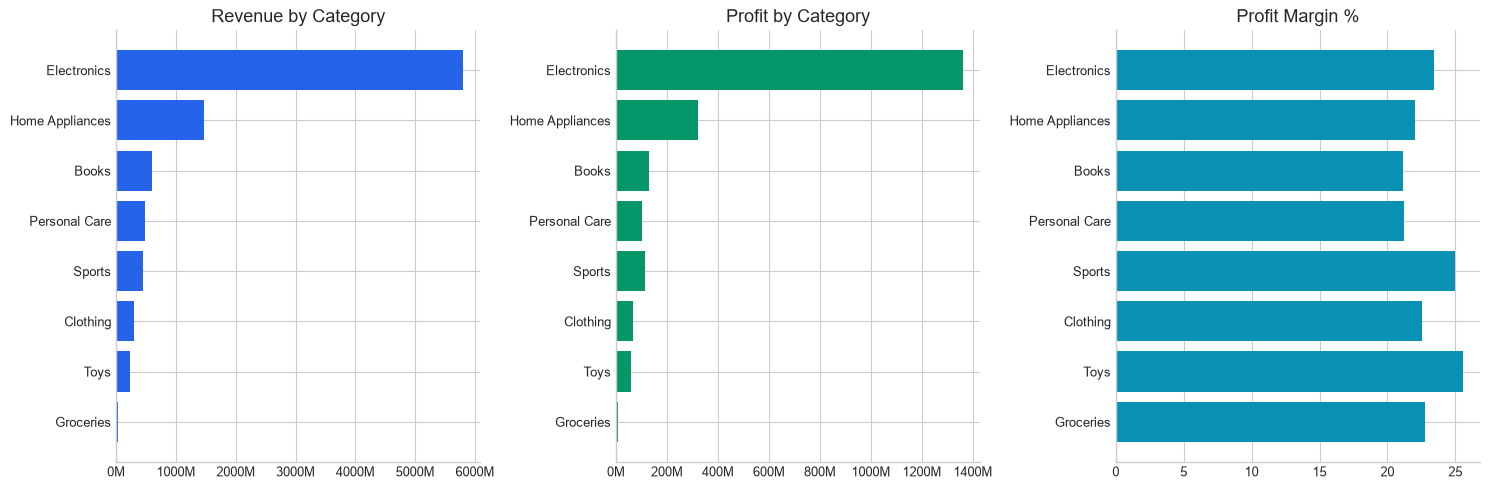

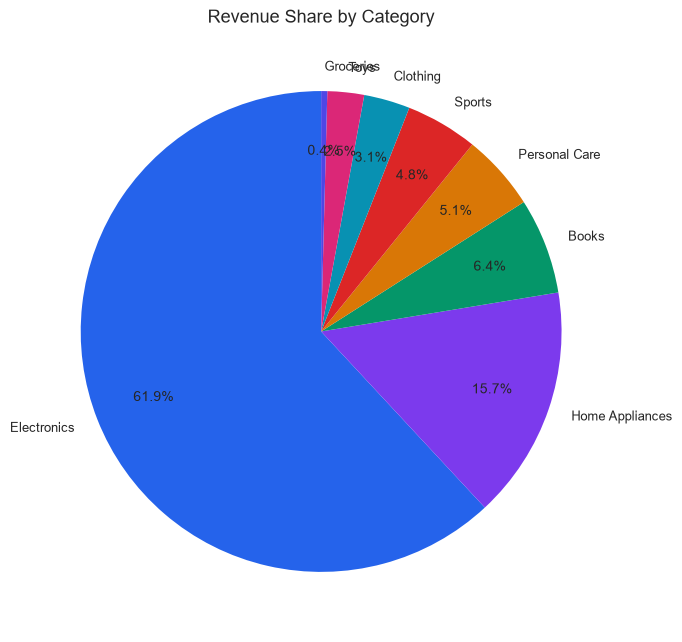

In [14]:
cat_perf = df.groupby("category").agg(
    revenue=("revenue", "sum"), profit=("profit", "sum"),
    quantity=("quantity_sold", "sum"), transactions=("sale_id", "count"),
    avg_price=("selling_price", "mean"), unique_products=("product_id", "nunique"),
).reset_index().sort_values("revenue", ascending=False)
cat_perf["profit_margin_pct"] = cat_perf["profit"] / cat_perf["revenue"] * 100
cat_perf["revenue_share_pct"] = cat_perf["revenue"] / cat_perf["revenue"].sum() * 100
display(cat_perf)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].barh(cat_perf["category"][::-1], cat_perf["revenue"][::-1], color=COLORS["primary"])
axes[0].set_title("Revenue by Category")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.0f}M"))
axes[1].barh(cat_perf["category"][::-1], cat_perf["profit"][::-1], color=COLORS["success"])
axes[1].set_title("Profit by Category")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.0f}M"))
axes[2].barh(cat_perf["category"][::-1], cat_perf["profit_margin_pct"][::-1], color=COLORS["info"])
axes[2].set_title("Profit Margin %")
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(cat_perf["revenue"], labels=cat_perf["category"], autopct="%1.1f%%",
       colors=COLORS["palette"][:len(cat_perf)], startangle=90, pctdistance=0.75)
ax.set_title("Revenue Share by Category")
plt.tight_layout(); plt.show()

,store_id,store_name,city,state,revenue,profit,quantity,transactions,profit_margin_pct,avg_transaction_value
2,3,SmartRetail Bangalore,Bangalore,Karnataka,"963,354,862.32","223,394,867.06",114316,30245,23.19,"31,851.71"
0,1,SmartRetail Mumbai,Mumbai,Maharashtra,"957,225,047.70","221,628,691.91",113407,30007,23.15,"31,900.06"
5,6,SmartRetail Chennai,Chennai,Tamil Nadu,"945,678,834.21","220,207,790.88",112399,29850,23.29,"31,681.03"
7,8,SmartRetail Ahmedabad,Ahmedabad,Gujarat,"937,973,913.85","219,240,198.83",112521,29886,23.37,"31,385.06"
3,4,SmartRetail Pune,Pune,Maharashtra,"933,120,669.45","212,707,688.82",114352,30266,22.80,"30,830.66"
6,7,SmartRetail Kolkata,Kolkata,West Bengal,"930,238,020.30","212,478,702.14",112738,29948,22.84,"31,061.77"
1,2,SmartRetail Delhi,New Delhi,Delhi,"929,600,978.57","212,939,450.22",113166,29977,22.91,"31,010.47"
8,9,SmartRetail Jaipur,Jaipur,Rajasthan,"927,441,437.40","214,767,107.42",113152,29856,23.16,"31,063.82"
4,5,SmartRetail Hyderabad,Hyderabad,Telangana,"924,818,902.47","213,274,424.42",113231,30121,23.06,"30,703.46"
9,10,SmartRetail Surat,Surat,Gujarat,"916,748,124.80","209,300,007.92",112870,29844,22.83,"30,718.00"


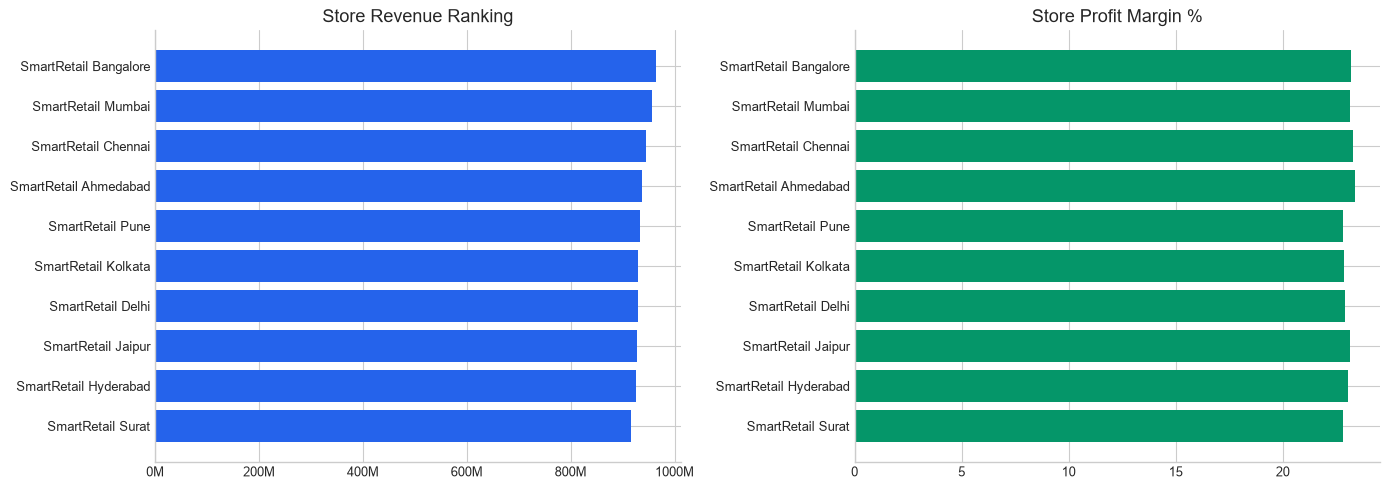

,city,state,revenue,profit,quantity,profit_margin_pct
1,Bangalore,Karnataka,"963,354,862.32","223,394,867.06",114316,23.19
6,Mumbai,Maharashtra,"957,225,047.70","221,628,691.91",113407,23.15
2,Chennai,Tamil Nadu,"945,678,834.21","220,207,790.88",112399,23.29
0,Ahmedabad,Gujarat,"937,973,913.85","219,240,198.83",112521,23.37
8,Pune,Maharashtra,"933,120,669.45","212,707,688.82",114352,22.80
5,Kolkata,West Bengal,"930,238,020.30","212,478,702.14",112738,22.84
7,New Delhi,Delhi,"929,600,978.57","212,939,450.22",113166,22.91
4,Jaipur,Rajasthan,"927,441,437.40","214,767,107.42",113152,23.16
3,Hyderabad,Telangana,"924,818,902.47","213,274,424.42",113231,23.06
9,Surat,Gujarat,"916,748,124.80","209,300,007.92",112870,22.83


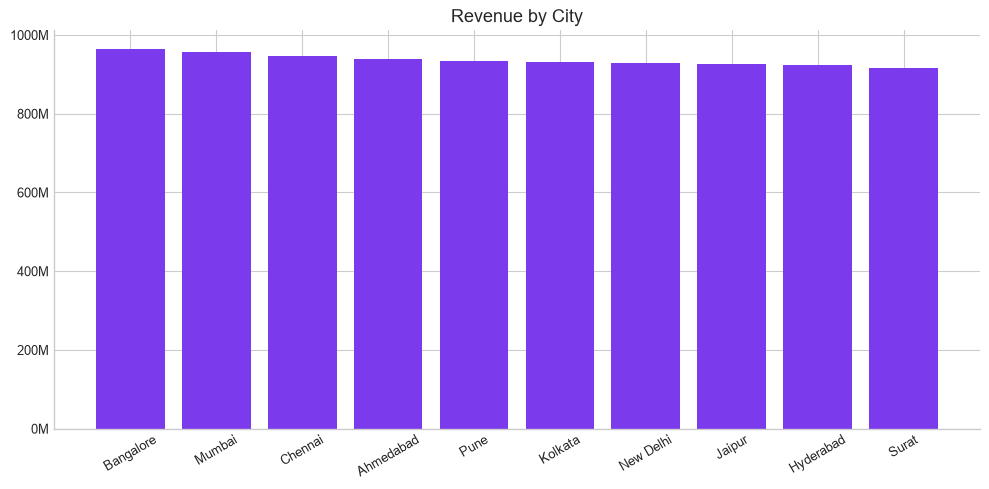

In [15]:
store_perf = df.groupby(["store_id", "store_name", "city", "state"]).agg(
    revenue=("revenue", "sum"), profit=("profit", "sum"),
    quantity=("quantity_sold", "sum"), transactions=("sale_id", "count"),
).reset_index().sort_values("revenue", ascending=False)
store_perf["profit_margin_pct"] = store_perf["profit"] / store_perf["revenue"] * 100
store_perf["avg_transaction_value"] = store_perf["revenue"] / store_perf["transactions"]
display(store_perf)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(store_perf["store_name"][::-1], store_perf["revenue"][::-1], color=COLORS["primary"])
axes[0].set_title("Store Revenue Ranking")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.0f}M"))
axes[1].barh(store_perf["store_name"][::-1], store_perf["profit_margin_pct"][::-1], color=COLORS["success"])
axes[1].set_title("Store Profit Margin %")
plt.tight_layout(); plt.show()

city_perf = df.groupby(["city", "state"]).agg(
    revenue=("revenue", "sum"), profit=("profit", "sum"), quantity=("quantity_sold", "sum")
).reset_index().sort_values("revenue", ascending=False)
city_perf["profit_margin_pct"] = city_perf["profit"] / city_perf["revenue"] * 100
display(city_perf)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(city_perf["city"], city_perf["revenue"], color=COLORS["secondary"])
ax.set_title("Revenue by City"); ax.tick_params(axis="x", rotation=30)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.0f}M"))
plt.tight_layout(); plt.show()

OVERALL FINANCIAL SNAPSHOT
Total Revenue      : 9,366,200,791.07
Total Profit       : 2,159,938,929.62
Overall Margin     : 23.06%
Total Units Sold   : 1,132,152
Avg Revenue / Txn  : 31,220.67
Avg Profit / Txn   : 7,199.80
Loss-making rows   : 54,619 (18.2%)


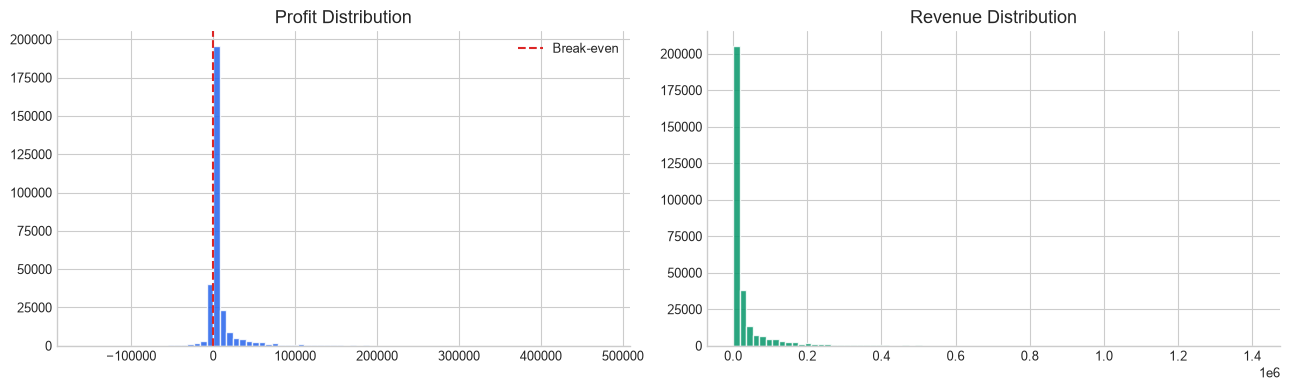

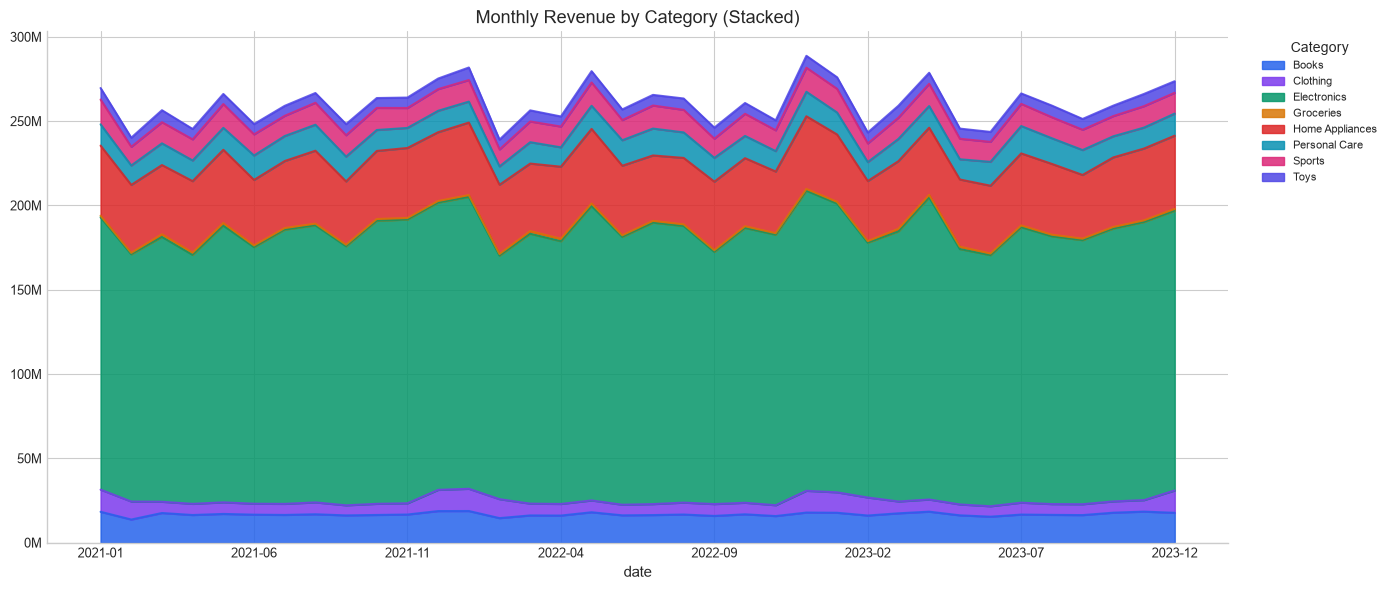

In [16]:
total_rev = df["revenue"].sum()
total_profit = df["profit"].sum()
total_qty = df["quantity_sold"].sum()

print("=" * 70)
print("OVERALL FINANCIAL SNAPSHOT")
print("=" * 70)
print(f"Total Revenue      : {total_rev:,.2f}")
print(f"Total Profit       : {total_profit:,.2f}")
print(f"Overall Margin     : {total_profit/total_rev*100:.2f}%")
print(f"Total Units Sold   : {total_qty:,}")
print(f"Avg Revenue / Txn  : {total_rev/len(df):,.2f}")
print(f"Avg Profit / Txn   : {total_profit/len(df):,.2f}")
print(f"Loss-making rows   : {(df['profit'] < 0).sum():,} ({(df['profit'] < 0).mean()*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(df["profit"], bins=80, color=COLORS["primary"], edgecolor="white", alpha=0.85)
axes[0].axvline(0, color=COLORS["danger"], linestyle="--", linewidth=1.5, label="Break-even")
axes[0].set_title("Profit Distribution"); axes[0].legend()
axes[1].hist(df["revenue"], bins=80, color=COLORS["success"], edgecolor="white", alpha=0.85)
axes[1].set_title("Revenue Distribution")
plt.tight_layout(); plt.show()

monthly_cat = df.groupby([df["date"].dt.to_period("M"), "category"])["revenue"].sum().unstack(fill_value=0)
monthly_cat.index = monthly_cat.index.astype(str)
fig, ax = plt.subplots(figsize=(14, 6))
monthly_cat.plot(kind="area", stacked=True, ax=ax, alpha=0.85,
                 color=COLORS["palette"][:monthly_cat.shape[1]])
ax.set_title("Monthly Revenue by Category (Stacked)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.0f}M"))
ax.legend(title="Category", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout(); plt.show()

,promo_flag,transactions,revenue,profit,quantity,avg_discount,avg_rev_per_txn,profit_margin_pct
4,None,148038,"5,258,187,950.72","1,779,333,170.95",545061,0.00,"35,519.18",33.84
1,20% Off,41094,"1,369,421,494.01","235,355,371.96",178218,0.20,"33,324.12",17.19
0,10% Off,36949,"1,171,311,586.01","310,346,335.23",136165,0.10,"31,700.77",26.50
3,Clearance,36744,"903,336,580.59","49,217,376.94",135585,0.30,"24,584.60",5.45
2,BOGO,37175,"663,943,179.74","-214,313,325.46",137123,0.50,"17,859.94",-32.28


,is_promo,transactions,revenue,profit,avg_qty,avg_rev,label
0,0,148038,"5,258,187,950.72","1,779,333,170.95",3.68,"35,519.18",No Promotion
1,1,151962,"4,108,012,840.35","380,605,758.67",3.86,"27,033.16",With Promotion


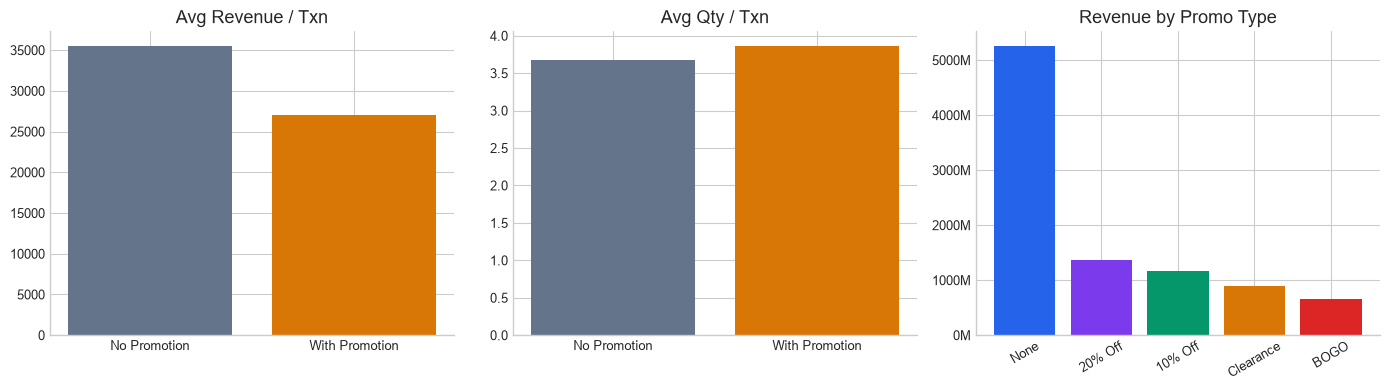


📈 Promotion lift on avg revenue/txn: -23.9%


In [17]:
df["promo_flag"] = df["promotion"].fillna("None").astype(str)
df.loc[df["promo_flag"].str.lower().isin(["none", "nan", "null", ""]), "promo_flag"] = "None"
df["is_promo"] = (df["promo_flag"] != "None").astype(int)

promo_summary = df.groupby("promo_flag").agg(
    transactions=("sale_id", "count"), revenue=("revenue", "sum"), profit=("profit", "sum"),
    quantity=("quantity_sold", "sum"), avg_discount=("discount_percent", "mean"),
).reset_index().sort_values("revenue", ascending=False)
promo_summary["avg_rev_per_txn"] = promo_summary["revenue"] / promo_summary["transactions"]
promo_summary["profit_margin_pct"] = promo_summary["profit"] / promo_summary["revenue"] * 100
display(promo_summary)

promo_cmp = df.groupby("is_promo").agg(
    transactions=("sale_id", "count"), revenue=("revenue", "sum"), profit=("profit", "sum"),
    avg_qty=("quantity_sold", "mean"), avg_rev=("revenue", "mean"),
).reset_index()
promo_cmp["label"] = promo_cmp["is_promo"].map({0: "No Promotion", 1: "With Promotion"})
display(promo_cmp)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].bar(promo_cmp["label"], promo_cmp["avg_rev"], color=[COLORS["muted"], COLORS["warning"]])
axes[0].set_title("Avg Revenue / Txn")
axes[1].bar(promo_cmp["label"], promo_cmp["avg_qty"], color=[COLORS["muted"], COLORS["warning"]])
axes[1].set_title("Avg Qty / Txn")
axes[2].bar(promo_summary["promo_flag"], promo_summary["revenue"],
            color=COLORS["palette"][:len(promo_summary)])
axes[2].set_title("Revenue by Promo Type"); axes[2].tick_params(axis="x", rotation=30)
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.0f}M"))
plt.tight_layout(); plt.show()

no_promo_avg = promo_cmp.loc[promo_cmp["is_promo"] == 0, "avg_rev"].values
promo_avg = promo_cmp.loc[promo_cmp["is_promo"] == 1, "avg_rev"].values
if len(no_promo_avg) and len(promo_avg) and no_promo_avg[0] > 0:
    lift = (promo_avg[0] / no_promo_avg[0] - 1) * 100
    print(f"\n📈 Promotion lift on avg revenue/txn: {lift:+.1f}%")

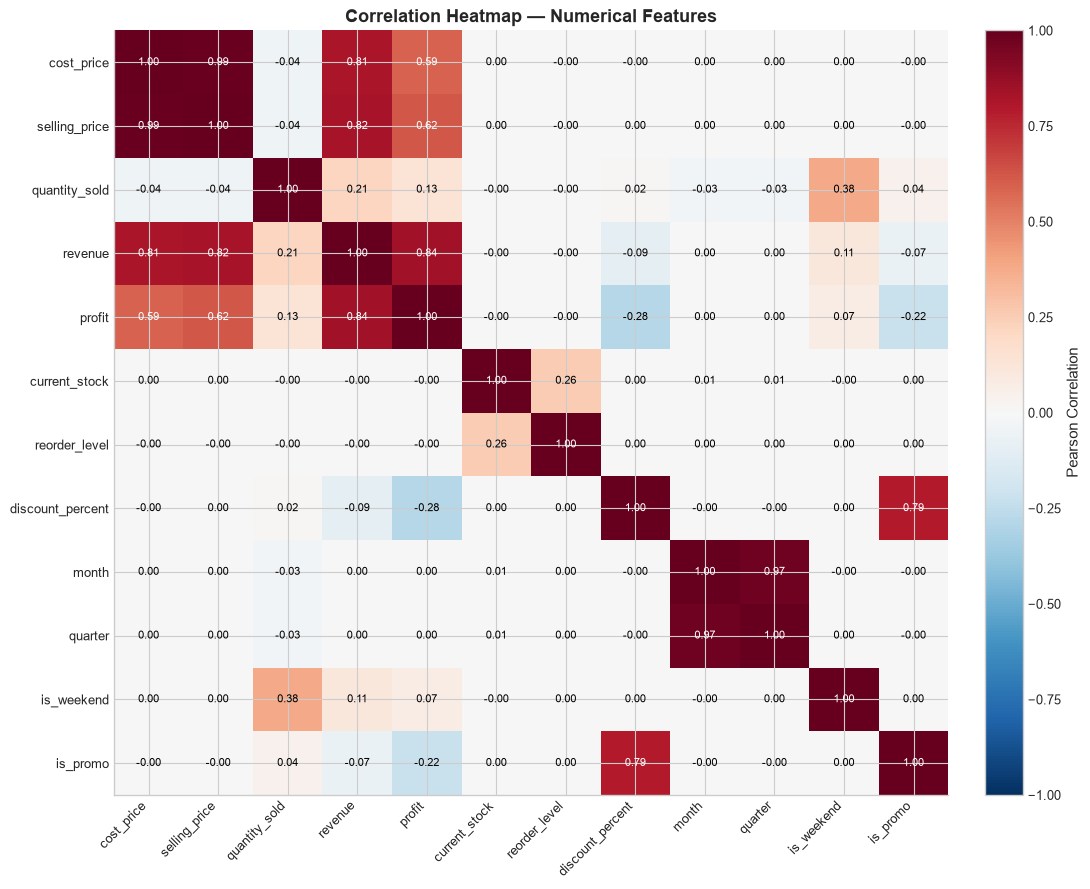

In [18]:
corr_cols = [
    "cost_price", "selling_price", "quantity_sold", "revenue", "profit",
    "current_stock", "reorder_level", "discount_percent",
    "month", "quarter", "is_weekend", "is_promo", "is_festival", "is_holiday",
]
corr_cols = [c for c in corr_cols if c in df.columns]
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(len(corr_cols))); ax.set_yticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=45, ha="right")
ax.set_yticklabels(corr_cols)

for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        val = corr.values[i, j]
        color = "white" if abs(val) > 0.55 else "black"
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=8, color=color)

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Pearson Correlation")
ax.set_title("Correlation Heatmap — Numerical Features", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

In [21]:
# ============================================================
# Cell 24 — Feature recommendations + save EDA summary
# Self-contained (does not depend on earlier cell variables)
# ============================================================

# Rebuild metrics from df (safe even if earlier cells were skipped)
total_rev = float(df["revenue"].sum())
total_profit = float(df["profit"].sum())

top_cat_name = (
    df.groupby("category")["revenue"].sum()
    .sort_values(ascending=False)
    .index[0]
)

inv_tmp = (
    df.sort_values("date")
    .groupby(["product_id", "product_name", "category"])
    .agg(
        last_stock=("current_stock", "last"),
        reorder_level=("reorder_level", "last"),
    )
    .reset_index()
)
inv_tmp["below_reorder"] = (inv_tmp["last_stock"] <= inv_tmp["reorder_level"]).astype(int)
products_below_reorder = int(inv_tmp["below_reorder"].sum())

print("""
FEATURE RECOMMENDATIONS
=======================
PROPHET:
  ds, y (daily revenue or quantity)
  Holidays: Republic Day, Holi, Eid, Diwali, Christmas
  Festival / promo regressors
  Built-in yearly + weekly seasonality

XGBOOST:
  Time: year, month, week_of_year, quarter, day, day_of_week, is_weekend,
        is_month_start, is_month_end
  Lag: lag_1, lag_7, lag_14, lag_30
  Rolling: mean/std/max/min (7, 14, 30)
  Business: is_promo, discount_percent, is_festival, is_holiday, season
  Entity: store_id, category, brand, product_id (encoded)
  Inventory: current_stock, reorder_level, stockout_flag
  Weather: weather (encoded)

NEXT: 02_preprocessing.ipynb
""")

summary = {
    "n_rows": int(len(df)),
    "date_min": str(df["date"].min().date()),
    "date_max": str(df["date"].max().date()),
    "total_revenue": total_rev,
    "total_profit": total_profit,
    "margin_pct": float(total_profit / total_rev * 100) if total_rev else 0.0,
    "n_stores": int(df["store_id"].nunique()),
    "n_products": int(df["product_id"].nunique()),
    "n_categories": int(df["category"].nunique()),
    "top_category": str(top_cat_name),
    "products_below_reorder": products_below_reorder,
}

from pathlib import Path
import json

out_dir = Path("../../datasets/processed")
out_dir.mkdir(parents=True, exist_ok=True)

with open(out_dir / "eda_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print(f"✅ EDA complete. Summary saved → {out_dir / 'eda_summary.json'}")
print("   (Model .pkl files come in Phase 5–6: Prophet / XGBoost training)")
display(summary)


FEATURE RECOMMENDATIONS
PROPHET:
  ds, y (daily revenue or quantity)
  Holidays: Republic Day, Holi, Eid, Diwali, Christmas
  Festival / promo regressors
  Built-in yearly + weekly seasonality

XGBOOST:
  Time: year, month, week_of_year, quarter, day, day_of_week, is_weekend,
        is_month_start, is_month_end
  Lag: lag_1, lag_7, lag_14, lag_30
  Rolling: mean/std/max/min (7, 14, 30)
  Business: is_promo, discount_percent, is_festival, is_holiday, season
  Entity: store_id, category, brand, product_id (encoded)
  Inventory: current_stock, reorder_level, stockout_flag
  Weather: weather (encoded)

NEXT: 02_preprocessing.ipynb

✅ EDA complete. Summary saved → ..\..\datasets\processed\eda_summary.json
   (Model .pkl files come in Phase 5–6: Prophet / XGBoost training)


{'n_rows': 300000,
 'date_min': '2021-01-01',
 'date_max': '2023-12-31',
 'total_revenue': 9366200791.070002,
 'total_profit': 2159938929.6200004,
 'margin_pct': 23.06099322234632,
 'n_stores': 10,
 'n_products': 200,
 'n_categories': 8,
 'top_category': 'Electronics',
 'products_below_reorder': 1}